## Setup

In [ ]:
using_colab = True

In [ ]:
!git clone https://github.com/facebookresearch/sam-3d-body
%cd sam-3d-body

Cloning into 'sam-3d-body'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 184 (delta 38), reused 14 (delta 14), pack-reused 70 (from 1)
Receiving objects: 100% (184/184), 22.39 MiB | 44.18 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/sam-3d-body


In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!pip install huggingface_hub

from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="facebook/sam-3d-body-dinov3",
    local_dir="./checkpoints/sam-3d-body-dinov3"
)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/content/sam-3d-body/checkpoints/sam-3d-body-dinov3'

In [ ]:
!pip install braceexpand
!pip install roma
!pip install pytorch-lightning
!pip install yacs
!pip install pyrender

# 1. Install prerequisites for building
!pip install 'git+https://github.com/facebookresearch/detectron2.git'
!pip install git+https://github.com/microsoft/MoGe.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 33.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 52.3 MB/s eta 0:00:00
  Created wheel for PyOpenGL: filename=PyOpenGL-3.1.0-py3-none-any.whl size=1745193 sha256=a36ea2039080d21e66a9c66d0d550e551844b15fece252a750e58b352f25236d
  Stored in directory: /root/.cache/pip/wheels/5c/d0/77/e69597cdbcb72ea27345036f549a737909bcf17c39789472ce
Successfully built PyOpenGL
  Attempting uninstall: PyOpenGL
    Found existing installation: PyOpenGL 3.1.10
    Uninstalling PyOpenGL-3.1.10:

In [ ]:
!nvidia-smi

Fri May 15 22:15:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

In [ ]:
import sys
import os
import importlib

# 1. Definimos la ruta raíz del repositorio
repo_root = '/content/sam-3d-body'

# 2. Forzamos a Python a mirar primero en tu carpeta local
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# 3. CRUCIAL: Eliminamos la referencia a la librería del sistema de la memoria
if 'notebook' in sys.modules:
    del sys.modules['notebook']
if 'notebook.utils' in sys.modules:
    del sys.modules['notebook.utils']

# 4. Intentamos la importación usando el espacio de nombres del paquete
try:
    # Intentamos la ruta que coincide con tu estructura de carpetas
    from sam_3d_body.notebook.utils import setup_sam_3d_body
    from sam_3d_body.tools.vis_utils import visualize_sample_together
    print("✅ Importación exitosa desde 'sam_3d_body'!")
except ImportError:
    try:
        # Intento alternativo si los archivos están en la raíz de la carpeta notebook/
        from notebook.utils import setup_sam_3d_body
        from tools.vis_utils import visualize_sample_together
        print("✅ Importación exitosa desde la raíz del repo!")
    except ImportError as e:
        print(f"❌ No se pudo importar: {e}")
        print("\nBuscando ubicación real del archivo...")
        !find /content/sam-3d-body -name "utils.py"

# 5. Inicializar el modelo
if 'setup_sam_3d_body' in locals():
    estimator = setup_sam_3d_body(
        hf_repo_id="facebook/sam-3d-body-dinov3"
    )

/content/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


✅ Importación exitosa desde la raíz del repo!
Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...
Downloading: "https://github.com/facebookresearch/dinov3/zipball/main" to /root/.cache/torch/hub/main.zip



missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parameter_transform, head_pose.mhr.character_torch.parameter_transform.pose_parameters, head_pose.mhr.character_torch.parameter_transform.rigid_parameters, head_pose.mhr.char

Loading human detector from vitdet...
########### Using human detector: ViTDet...


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
model_final_f05665.pkl: 2.77GB [00:55, 50.2MB/s]                            


Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...


model.pt:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓


## Load segmented frames of a video

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from importlib.machinery import SourceFileLoader

# 1. CONFIGURACIÓN DE RUTAS
ruta_base = f"/content/drive/MyDrive/TFG/Press/Img"

ruta_entrada = os.path.join(ruta_base, "Segmented_Frames/bench_press_10")
ruta_salida = os.path.join(ruta_base, "Estimated_Pose_Frames/bench_press_10")
ruta_data_keypoints = os.path.join(ruta_base, "Keypoints/bench_press_10")

os.makedirs(ruta_salida, exist_ok=True)
os.makedirs(ruta_data_keypoints, exist_ok=True)

# 2. CARGAR UTILIDADES (vis_utils)
repo_3d = '/content/sam-3d-body'
vis_utils_path = os.path.join(repo_3d, 'tools/vis_utils.py')

if os.path.exists(vis_utils_path):
    vis_utils = SourceFileLoader("vis_utils", vis_utils_path).load_module()
    print("✅ Módulo 'vis_utils' cargado correctamente.")
else:
    raise FileNotFoundError("No se encontró vis_utils.py en el repositorio.")

# 3. OBTENER LISTA DE FRAMES (Ordenados para el vídeo)
frame_files = sorted([f for f in os.listdir(ruta_entrada) if f.endswith('.png')])
n_frames = len(frame_files)
print(f"🔎 Se han encontrado {len(frame_files)} frames para procesar.")

# 4. BUCLE DE PROCESAMIENTO
# Usamos tqdm para ver la barra de progreso
all_keypoints = np.full((n_frames, 127, 3), np.nan)

for i, filename in enumerate(tqdm(frame_files, desc="Procesando Biomecánica 3D")):

    # A. Cargar imagen
    img_path = os.path.join(ruta_entrada, filename)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue

    # B. Preparar imagen para el modelo
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # C. Inferencia (Estimación de Pose 3D)
    with torch.no_grad(): # Ahorramos memoria GPU
        outputs = estimator.process_one_image(img_rgb)

    # D. Verificación de detección
    if outputs is not None and len(outputs) > 0:
        res = outputs[0] if isinstance(outputs, list) else outputs

        if 'pred_joint_coords' in res:
            joints = res['pred_joint_coords'] # (127, 3)
            if hasattr(joints, "cpu"): joints = joints.cpu().numpy()

            # Guardamos los 127 puntos
            all_keypoints[i] = joints

        # E. Renderizado visual
        try:
            outputs_list = outputs if isinstance(outputs, list) else [outputs]
            rendered = vis_utils.visualize_sample_together(img_rgb, outputs_list, estimator.faces)
            cv2.imwrite(os.path.join(ruta_salida, filename), cv2.cvtColor(rendered, cv2.COLOR_RGB2BGR))
        except:
            pass
    else:
        # Frame negro si no hay detección
        h, w = img_rgb.shape[:2]
        cv2.imwrite(os.path.join(ruta_salida, filename), np.zeros((h*2, w*2, 3), np.uint8))

# F. Guardado
archivo_npy = os.path.join(ruta_data_keypoints, "keypoints_3d_bench_press_10.npy")
np.save(archivo_npy, all_keypoints)

print(f"\n✅ PROCESO COMPLETADO")
print(f"📂 Todos los frames con pose estimada están en: {ruta_salida}")

✅ Módulo 'vis_utils' cargado correctamente.
🔎 Se han encontrado 53 frames para procesar.


Procesando Biomecánica 3D:   0%|          | 0/53 [00:00<?, ?it/s]

####### Please make sure the input image is in RGB format
Running object detector...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0515 22:19:06.580000 624 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Found boxes: [[ 360.50763  280.91187 1239.4739  1069.4778 ]]
Running FOV estimator ...


...

####### Please make sure the input image is in RGB format
Running object detector...
Found boxes: [[ 359.40955  265.52695 1238.3253  1069.7784 ]]
Running FOV estimator ...


Procesando Biomecánica 3D:  98%|█████████▊| 52/53 [09:58<00:11, 11.35s/it]

####### Please make sure the input image is in RGB format
Running object detector...
Found boxes: [[ 359.7223  265.5933 1238.2711 1069.9569]]
Running FOV estimator ...


Procesando Biomecánica 3D: 100%|██████████| 53/53 [10:09<00:00, 11.51s/it]



✅ PROCESO COMPLETADO
📂 Todos los frames con pose estimada están en: /content/drive/MyDrive/TFG/Press/Img/Estimated_Pose_Frames/bench_press_10


In [ ]:
import cv2
import os
import time
import shutil
from tqdm import tqdm

# 1. Rutas de ENTRADA (Desde tu Drive)
nombre_acceso_directo = "TFG"
ruta_base_drive = f"/content/drive/MyDrive/{nombre_acceso_directo}/Press"
ruta_frames_pose = os.path.join(ruta_base_drive, "Img/Estimated_Pose_Frames/bench_press_10")

# 2. Rutas de PROCESO (En el disco local de Colab, mucho más rápido y sin errores)
video_temp_local = "/content/temp_raw.mp4"
video_final_local = "/content/video_final_compatible.mp4"

# 3. Ruta de SALIDA (A tu Drive)
video_salida_drive = os.path.join(ruta_base_drive, "Vid/bench_press_10_estimated_pose.mp4")
os.makedirs(os.path.dirname(video_salida_drive), exist_ok=True)

# --- PASO 1: UNIR FRAMES ---
frame_files = sorted([f for f in os.listdir(ruta_frames_pose) if f.endswith('.png')])
primer_frame = cv2.imread(os.path.join(ruta_frames_pose, frame_files[0]))
alto, ancho, _ = primer_frame.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_temp_local, fourcc, 30, (ancho, alto))

print(f"🎬 Paso 1/3: Uniendo {len(frame_files)} frames en disco local...")
for filename in tqdm(frame_files, desc="Generando MP4"):
    frame = cv2.imread(os.path.join(ruta_frames_pose, filename))
    if frame is not None:
        out.write(frame)
out.release()

# --- PASO 2: CONVERTIR CON FFMEPG (En disco local) ---
print(f"🔄 Paso 2/3: Convirtiendo a H.264 compatible...")
# Aquí FFmpeg no fallará porque lee y escribe en el disco duro de la máquina virtual
os.system(f'ffmpeg -i "{video_temp_local}" -vcodec libx264 -crf 23 -pix_fmt yuv420p -y "{video_final_local}"')

# --- PASO 3: MOVER AL DRIVE ---
print(f"📂 Paso 3/3: Trasladando vídeo final al Google Drive...")
if os.path.exists(video_final_local) and os.path.getsize(video_final_local) > 0:
    shutil.copy(video_final_local, video_salida_drive)
    print(f"\n✅ ¡PROCESO COMPLETADO!")
    print(f"📍 Tu vídeo está aquí: {video_salida_drive}")

    # Limpieza del disco local de Colab
    os.remove(video_temp_local)
    os.remove(video_final_local)
else:
    print("\n❌ Error crítico: El vídeo no se pudo convertir en el disco local.")

🎬 Paso 1/3: Uniendo 53 frames en disco local...


Generando MP4: 100%|██████████| 53/53 [00:07<00:00,  6.89it/s]


🔄 Paso 2/3: Convirtiendo a H.264 compatible...
📂 Paso 3/3: Trasladando vídeo final al Google Drive...

✅ ¡PROCESO COMPLETADO!
📍 Tu vídeo está aquí: /content/drive/MyDrive/TFG/Press/Vid/bench_press_10_estimated_pose.mp4


In [ ]:
import numpy as np

def calcular_distancia_3d(p1, p2):
    """Calcula la distancia euclídea entre dos puntos en el espacio 3D."""
    return np.linalg.norm(p1 - p2)

def calcular_angulo_3d(p1, p2, p3):
    """Calcula el ángulo en el punto p2 formado por p1-p2 y p3-p2"""
    v1 = p1 - p2
    v2 = p3 - p2

    # Producto escalar y normas
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    if norm_v1 < 1e-6 or norm_v2 < 1e-6:
        return np.nan  # evitar basura

    # Coseno del ángulo con clip para evitar errores numéricos
    cos_theta = dot_product / (norm_v1 * norm_v2)
    angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    return np.degrees(angle)

def calcular_grip_ratio(frame_data):
    # 1. Distancia entre muñecas (Ancho del agarre)
    # Usamos 3D para captar la distancia real entre manos aunque estén en diagonal
    dist_agarre = np.linalg.norm(frame_data[78] - frame_data[42])

    # 2. Referencia: Longitud de un brazo (Hombro -> Codo -> Muñeca)
    # Esta medida es constante aunque el sujeto gire
    arm_l = np.linalg.norm(frame_data[75] - frame_data[76]) + \
            np.linalg.norm(frame_data[76] - frame_data[78])

    # 3. Ratio basado en brazo
    ratio = dist_agarre / arm_l
    return ratio

def calcular_inclinacion_torso(p_shoulder, p_hip):
    # Vector que va desde la cadera hacia el hombro (hacia arriba)
    # Importante: Usamos X e Y (0 y 1). Asegúrate de qué eje es la altura en tu .npy
    # Si el eje 1 (Y) es la altura:
    v_torso = np.array([p_shoulder[0] - p_hip[0], p_shoulder[1] - p_hip[1]])

    # La vertical pura en este plano
    vertical = np.array([0, -1]) # Probamos -1 si Y crece hacia abajo

    v_torso /= (np.linalg.norm(v_torso) + 1e-6)
    dot = np.dot(v_torso, vertical)
    angulo = np.degrees(np.arccos(np.clip(dot, -1, 1)))

    # Si el ángulo sale > 90, es que el vector está invertido
    return angulo if angulo < 90 else 180 - angulo

def calcular_ratio_apertura(hip_izq, knee_izq, hip_der, knee_der):
    """
    Mide la apertura de las rodillas comparada con las caderas.
    Si las rodillas están más abiertas que las caderas, el ratio es > 1.
    """
    dist_caderas = calcular_distancia_3d(hip_izq, hip_der)
    dist_rodillas = calcular_distancia_3d(knee_izq, knee_der)

    if dist_caderas == 0: return 1.0
    return dist_rodillas / dist_caderas

def calibrar_antropometria(data):
    """
    Calcula el tipo de cuerpo usando las distancias máximas encontradas
    en todo el vídeo para evitar errores de perspectiva en el lockout.
    """
    # Calculamos las longitudes para todos los frames
    # Usamos np.linalg.norm en los 3 ejes (X, Y, Z) para mitigar la perspectiva

    # Segmento Torso: Hombro a Cadera
    torsos = np.linalg.norm(data[:, 75] - data[:, 2], axis=1)
    # Segmento Pierna: Cadera a Tobillo
    piernas = np.linalg.norm(data[:, 2] - data[:, 4], axis=1)

    # Filtramos posibles ceros o errores de detección (NaN)
    longitud_torso = np.nanpercentile(torsos, 90) # Usamos el percentil 90 para evitar picos de ruido
    longitud_pierna = np.nanpercentile(piernas, 90)

    ratio = longitud_torso / longitud_pierna

    if ratio > 0.68: # Umbrales ligeramente ajustados
        tipo = "Torso Largo"
    elif ratio < 0.58:
        tipo = "Piernas Largas"
    else:
        tipo = "Estandar"

    return tipo, ratio

def calcular_desplazamiento_normalizado(p_actual, p_referencia, longitud_brazo):
    """
    Calcula cuánto se ha movido un punto respecto a su inicio,
    normalizado por el tamaño del brazo del atleta.
    """
    distancia_abs = np.linalg.norm(p_actual - p_referencia)
    return distancia_abs / longitud_brazo

In [ ]:
def analizar_tecnica_lateral_raise(max_abduction_angle, min_elbow_angle, max_torso_angle):
    """
    Evalúa la técnica de Elevaciones Laterales.
    """
    # REGLA 1 y 2: RANGO DE MOVIMIENTO (Abducción)
    if max_abduction_angle >= 80 and max_abduction_angle <= 110:
        es_correcta = True
        msg_rom = "✅ TÉCNICA CORRECTA: Rango de elevación ideal."
    elif max_abduction_angle < 80:
        es_correcta = False
        msg_rom = "❌ TÉCNICA INCORRECTA: Elevación insuficiente (sube más)."
    else:
        es_correcta = False
        msg_rom = "⚠️ AVISO: Elevación excesiva (riesgo de pinzamiento)."

    # REGLA 3: ESTADO DEL CODO (Evitar curl)
    msg_codo = "✅ Codos estables y ligeramente flexionados."
    if min_elbow_angle < 130:
        msg_codo = "⚠️ AVISO: Codos demasiado doblados."

    # REGLA 4: ESTABILIDAD DEL TORSO (Balanceo)
    msg_torso = "✅ Torso estable."
    if max_torso_angle > 30:
        msg_torso = "⚠️ AVISO: Balanceo del torso detectado (uso de impulso)."


    return es_correcta, msg_rom, msg_codo, msg_torso

Calibración: Reposo detectado en Frame 57 (Ángulo: 31.0°)
     INFORME BIOMECÁNICO: LATERAL RAISES 
Análisis realizado en el Frame (Pico): 26
-> Abducción máx. hombro: 116.86°
-> Ángulo mín. codo:      107.24°
-> Inclinación máx torso: 12.12°
-----------------------------------------
VERDICTO PRINCIPAL:
⚠️ AVISO: Elevación excesiva (riesgo de pinzamiento).

OBSERVACIONES TÉCNICAS:
⚠️ AVISO: Codos demasiado doblados.
✅ Torso estable.


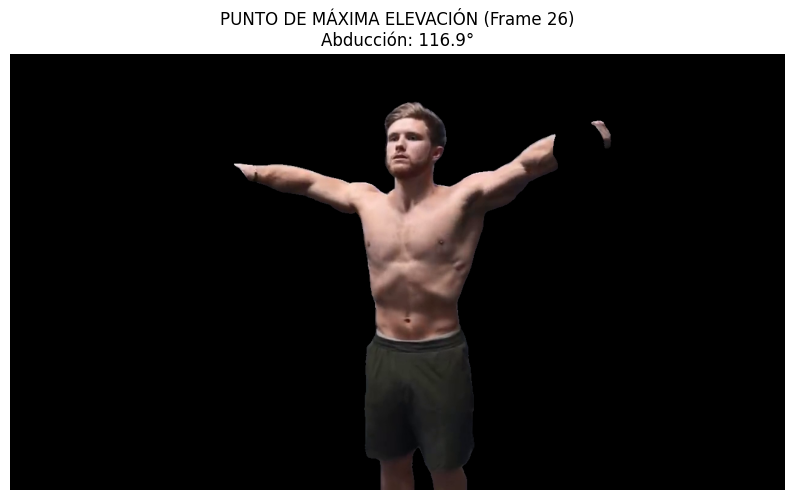

In [ ]:
import os
import matplotlib.pyplot as plt

# --- 1. CARGA Y CALIBRACIÓN DE REPOSO ---
# Ajusta la ruta a tu archivo .npy de Lateral Raises
data = np.load('/content/drive/MyDrive/TFG/Lateral/Img/Keypoints/lateral_raise_8/keypoints_3d_lateral_raise_8.npy')

# Encontramos el reposo (brazos pegados al cuerpo = ángulo de hombro mínimo)
angulos_hombro_calib = []
for f in range(len(data)):
    # Ángulo entre codo-hombro-cadera (abducción)
    a = calcular_angulo_3d(data[f, 76], data[f, 75], data[f, 2])
    angulos_hombro_calib.append(a)

idx_reposo = np.nanargmin(angulos_hombro_calib)
shoulder_ref = data[idx_reposo, 75]

print(f"Calibración: Reposo detectado en Frame {idx_reposo} (Ángulo: {angulos_hombro_calib[idx_reposo]:.1f}°)")

metrics_per_frame = []

# --- 2. BUCLE DE PROCESAMIENTO ---
for frame in range(len(data)):
    shoulder = data[frame, 75]
    elbow    = data[frame, 76]
    wrist    = data[frame, 78]
    hip      = data[frame, 2]

    # Métrica 1: Abducción de hombro
    ang_abduccion = calcular_angulo_3d(elbow, shoulder, hip)

    # Métrica 2: Ángulo de codo (estabilidad)
    ang_codo = calcular_angulo_3d(shoulder, elbow, wrist)

    # Métrica 3: Inclinación torso
    inc_torso = calcular_inclinacion_torso(shoulder, hip)

    metrics_per_frame.append([ang_abduccion, ang_codo, inc_torso])

metrics_array = np.array(metrics_per_frame)

# --- 3. EXTRACCIÓN DE RESULTADOS (Punto más alto) ---
idx_peak = np.nanargmax(metrics_array[:, 0]) # Máxima abducción

max_abd_val    = metrics_array[idx_peak, 0]
min_codo_val   = np.nanmin(metrics_array[:, 1])
max_torso_val  = np.nanmax(metrics_array[:, 2])

# --- 4. LLAMADA A REGLAS ---
es_ok, txt_rom, txt_codo, txt_torso = analizar_tecnica_lateral_raise(
    max_abd_val, min_codo_val, max_torso_val
)

# --- 5. INFORME FINAL ---
print("=========================================")
print("     INFORME BIOMECÁNICO: LATERAL RAISES ")
print("=========================================")
print(f"Análisis realizado en el Frame (Pico): {idx_peak}")
print(f"-> Abducción máx. hombro: {max_abd_val:.2f}°")
print(f"-> Ángulo mín. codo:      {min_codo_val:.2f}°")
print(f"-> Inclinación máx torso: {max_torso_val:.2f}°")
print("-----------------------------------------")
print(f"VERDICTO PRINCIPAL:")
print(txt_rom)
print("\nOBSERVACIONES TÉCNICAS:")
print(txt_codo)
print(txt_torso)
print("=========================================")

# --- 6. VALIDACIÓN VISUAL ---
folder_path = '/content/drive/MyDrive/TFG/Lateral/Img/Segmented_Frames/lateral_raise_8/'
filename = f"frame_{idx_peak + 1:04d}.png"
img_path = os.path.join(folder_path, filename)

try:
    import matplotlib.image as mpimg
    plt.figure(figsize=(10, 7))
    plt.imshow(mpimg.imread(img_path))
    plt.title(f"PUNTO DE MÁXIMA ELEVACIÓN (Frame {idx_peak})\nAbducción: {max_abd_val:.1f}°")
    plt.axis('off')
    plt.show()
except:
    print(f"⚠️ Imagen no encontrada en {img_path}")

In [ ]:
import numpy as np
from scipy.signal import find_peaks
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os

# Índices según la jerarquía de SAM-3D Body (127 joints)
IDX_R_WRIST = 42
IDX_L_WRIST = 78
IDX_R_SHOULDER = 39
IDX_L_SHOULDER = 75
IDX_ROOT = 1

def cargar_datos_vbt(npy_path, idx_r, idx_l):
    data = np.load(npy_path)
    # data.shape -> (Frames, 127, 3)

    # Extraemos los puntos seleccionados dinámicamente
    p_r = data[:, idx_r, :]
    p_l = data[:, idx_l, :]
    return p_r, p_l, data.shape[0]

def calcular_elc_3d(wrist_r, wrist_l):
    """
    Calcula el Estimated Load Center (ELC) promediando las muñecas.
    Retorna un array de (Frames, 3)
    """
    elc = (wrist_r + wrist_l) / 2
    return elc

def extraer_eje_principal(elc, eje=1):
    """
    Extrae la trayectoria en el eje vertical (por defecto Y).
    Retorna un array de (Frames,)
    """
    return elc[:, eje]

def extraer_info_video(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Error: No se pudo abrir el vídeo en {video_path}")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duracion = total_frames_video / fps

    cap.release()
    return {
        "fps": fps,
        "total_frames": total_frames_video,
        "duracion_seg": duracion
    }

class VBT_Session:
    def __init__(self, npy_path, video_path, modo="push"):
        """
        modo:
          "push"  -> Press Banca/Inclinado (Muñecas + Concéntrica hacia arriba)
          "pdown" -> Jalón/Tríceps (Muñecas + Concéntrica hacia abajo)
          "squat" -> Sentadilla (Hombros + Concéntrica hacia arriba)
          "deadlift" -> Deadlift (Muñecas + Concéntrica hacia arriba)
        """
        # 1. Extraer metadatos reales del vídeo
        video_info = extraer_info_video(video_path)
        if video_info is None: return

        self.fps = video_info["fps"]
        self.dt = 1.0 / self.fps  # Tiempo exacto entre frames
        self.modo = modo
        self.total_frames_video = video_info["total_frames"]

        # Índices para el suelo
        IDX_L_BALL, IDX_R_BALL = 8, 24

        # 2. Cargar datos de SAM-3D
        data = np.load(npy_path)
        self.total_frames_npy = data.shape[0]

        # 3. Selección de puntos y Cálculo de Trayectoria
        if modo == "squat":
            idx_r, idx_l = IDX_R_SHOULDER, IDX_L_SHOULDER

            # 1. ELC de los hombros (Carga)
            elc_hombros_y = (data[:, idx_r, 1] + data[:, idx_l, 1]) / 2

            # 2. Posición del suelo (Promedio de los pies)
            # Usamos los índices que ya definiste: IDX_L_BALL=8, IDX_R_BALL=24
            suelo_y = (data[:, IDX_L_BALL, 1] + data[:, IDX_R_BALL, 1]) / 2

            # 3. Trayectoria = Hombros - Suelo
            # Mantenemos el signo original del modelo para no romper tu lógica de find_peaks
            self.trayectoria_raw = elc_hombros_y - suelo_y

            print("🏋️ Modo SQUAT: Referencia de hombros respecto al suelo (tobillos) aplicada.")

        elif modo == "deadlift":
            # --- CAMBIO PARA PESO MUERTO ---
            idx_r, idx_l = IDX_R_WRIST, IDX_L_WRIST
            # Calculamos la altura de las muñecas
            elc_muñecas_y = (data[:, idx_r, 1] + data[:, idx_l, 1]) / 2
            # Calculamos la posición del suelo (tobillos)
            suelo_y = (data[:, IDX_L_BALL, 1] + data[:, IDX_R_BALL, 1]) / 2

            # Trayectoria = Muñecas respecto al suelo
            self.trayectoria_raw = elc_muñecas_y - suelo_y
            print("💪 Modo DEADLIFT: Referencia Muñecas respecto al suelo (tobillo) aplicada.")

        elif modo in ["curl", "lateral"]:
            # Ambos usan muñecas y análisis de arco
            idx_r, idx_l = IDX_R_WRIST, IDX_L_WRIST
            wr = data[:, idx_r, :]
            wl = data[:, idx_l, :]
            self.elc_3d = (wr + wl) / 2
            self.trayectoria_raw = self.elc_3d[:, 1]
            print(f"💪 Modo {modo.upper()}: Analizando trayectoria circular de Muñecas.")

        elif modo == "pecfly":
            idx_r, idx_l = IDX_R_WRIST, IDX_L_WRIST
            wr = data[:, idx_r, :]
            wl = data[:, idx_l, :]
            self.elc_3d = (wr + wl) / 2
            # Distancia euclidiana entre muñeca derecha e izquierda en cada frame
            self.trayectoria_raw = np.linalg.norm(wr - wl, axis=1)
            print("🦅 Modo PEC FLY: Analizando apertura y cierre horizontal de Muñecas.")

        else:
            # Tu lógica original para push/pdown
            idx_r, idx_l = IDX_R_WRIST, IDX_L_WRIST
            wr = data[:, idx_r, :]
            wl = data[:, idx_l, :]
            self.elc_3d = (wr + wl) / 2
            self.trayectoria_raw = self.elc_3d[:, 1]
            print(f"💪 Modo {modo.upper()}: Usando Muñecas sin referencia de suelo.")

        # 4. Sincronización Check
        if self.total_frames_video != self.total_frames_npy:
            print(f"⚠️ Aviso: Desfase de frames. Vídeo: {self.total_frames_video} | NPY: {self.total_frames_npy}")

        # 5. Inicializar diccionarios
        self.metricas_finales = {}
        self.metricas_serie = {}

        print(f"✅ Sesión sincronizada correctamente.")
        print(f"📊 FPS: {self.fps:.2f} | DeltaT: {self.dt:.4f}s")
        print(f"📍 Trayectoria cargada: {len(self.trayectoria_raw)} puntos.")

    def procesar_fisica(self, suavizado=True):
        """
        Calcula velocidad y aceleración a partir de la trayectoria del ELC.
        """
        y = self.trayectoria_raw.copy()

        # 1. Suavizado (Opcional pero muy recomendado para VBT)
        if suavizado:
            # Usamos una media móvil simple para limpiar el ruido del sensor
            window = 3
            y = np.convolve(y, np.ones(window)/window, mode='same')

        self.posicion = y

        if self.modo in ["curl", "lateral", "pecfly"]:
            # Calculamos la velocidad real (módulo del vector 3D)
            # Distancia euclidiana entre frames consecutivos
            diffs = np.diff(self.elc_3d, axis=0)
            distancias = np.sqrt(np.sum(diffs**2, axis=1))
            # Insertamos un 0 al inicio para mantener el tamaño original
            v_modulo = np.insert(distancias / self.dt, 0, 0)

            signo_y = np.sign(np.gradient(self.posicion))
            self.velocidad = v_modulo * signo_y
        else:
            # 2. Velocidad: np.gradient calcula la derivada central
            # v = dy / dt
            self.velocidad = np.gradient(self.posicion, self.dt)

        # 3. Aceleración: Derivada de la velocidad
        # a = dv / dt
        self.aceleracion = np.gradient(self.velocidad, self.dt)

        print(f"✨ Física calculada para {len(self.posicion)} frames.")

    def graficar_analisis(self):
        # Creamos una figura con 2 subplots verticales
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

        # Recortamos bordes para evitar ruidos de inicio/fin
        f_start, f_end = 2, -2
        frames = np.arange(len(self.posicion))[f_start:f_end]
        pos_plot = self.posicion[f_start:f_end]
        vel_plot = self.velocidad[f_start:f_end]

        # Separamos por fases usando el signo
        vel_concentrica = vel_plot[vel_plot > 0]
        vel_excentrica = vel_plot[vel_plot < 0]

        # 1. Gráfica de POSICIÓN
        ax1.plot(frames, pos_plot, color='tab:blue', linewidth=3, label="Posición (Y)")
        ax1.set_ylabel('Posición (Y)')
        ax1.set_title("Análisis Biomecánico del ELC")
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        # 2. Gráfica de VELOCIDAD
        ax2.plot(frames, vel_plot, color='tab:red', linestyle='--', label="Velocidad (m/s)")
        ax2.fill_between(frames, 0, vel_plot, color='tab:red', alpha=0.1)
        ax2.axhline(0, color='black', linewidth=1)
        ax2.set_ylabel('Velocidad (m/s)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()

        plt.tight_layout()
        plt.show()

    def calcular_metricas_vbt(self):
        """
        Segmenta repeticiones usando una lógica de puntos críticos:
        - Pico (P): Barra en el pecho (valor menos negativo).
        - Valle (V): Barra arriba/bloqueo (valor más negativo).
        """
        y = np.array(self.posicion)
        v_array = self.velocidad
        fps = self.fps

        # Inicializar listas de métricas
        self.reps_rom = []
        self.reps_vmc = []
        self.reps_vme = []
        self.reps_tc = []
        self.reps_te = []
        self.reps_tut = []
        self.reps_indices = []

        reps_encontradas = []

        # Detección de puntos:
        if self.modo in ["deadlift", "curl", "lateral"]:
            # 1. Encontrar los puntos más altos
            valles_bloqueo, _ = find_peaks(-y, distance=int(fps * 0.8), prominence=0.02)

            for v in valles_bloqueo:
                # 2. Para cada bloqueo, buscamos (en un rango de 2 segundos alrededor) el "suelo" (máximo Y) hacia atrás y hacia adelante
                ventana = int(fps * 2.0)
                idx_inicio_busqueda = max(0, v - ventana)
                idx_fin_busqueda = min(len(y) - 1, v + ventana)

                f_ini = idx_inicio_busqueda + np.argmax(y[idx_inicio_busqueda:v])
                f_fin = v + np.argmax(y[v:idx_fin_busqueda])

                # Filtro de seguridad:
                if np.abs(y[f_ini] - y[v]) > 0.20:
                    reps_encontradas.append({'f_ini': f_ini, 'f_mid': v, 'f_fin': f_fin, 'tipo': 'deadlift'})

        elif self.modo == "pecfly":
            # El punto medio (f2) es cuando las manos están más juntas (mínima distancia)
            # Buscamos valles en la distancia entre manos
            valles_cierre, _ = find_peaks(-self.trayectoria_raw, distance=int(fps * 0.8), prominence=0.05)

            for v in valles_cierre:
                ventana = int(fps * 2.0)
                idx_i = max(0, v - ventana)
                idx_f = min(len(self.trayectoria_raw) - 1, v + ventana)

                # f_ini y f_fin son los puntos de máxima apertura (máxima distancia)
                f_ini = idx_i + np.argmax(self.trayectoria_raw[idx_i:v])
                f_fin = v + np.argmax(self.trayectoria_raw[v:idx_f])

                if np.abs(self.trayectoria_raw[f_ini] - self.trayectoria_raw[v]) > 0.15:
                    reps_encontradas.append({'f_ini': f_ini, 'f_mid': v, 'f_fin': f_fin, 'tipo': 'pecfly'})

        else:
            # 1. Buscamos los valles (barra arriba)
            picos_bajo, _ = find_peaks(y, distance=int(fps * 0.8), prominence=0.03)

            # Aseguramos que los picos estén ordenados cronológicamente
            picos_bajo = np.sort(picos_bajo)
            ultimo_f_fin_registrado = 0

            for p in picos_bajo:
                # Filtro perimetral base
                if len(y) - p < int(fps * 0.5):
                    continue

                ventana = int(fps * 2.5)

                # Acotar el inicio con la frontera de la repetición anterior
                idx_inicio_busqueda = max(ultimo_f_fin_registrado, p - ventana)
                idx_fin_busqueda = min(len(y) - 1, p + ventana)

                # Implementamos control de seguridad antivacío
                if idx_inicio_busqueda >= p or p >= idx_fin_busqueda:
                    continue

                # Buscamos el punto más alto antes y después del fondo
                f_ini = idx_inicio_busqueda + np.argmin(y[idx_inicio_busqueda:p])
                f_fin = p + np.argmin(y[p:idx_fin_busqueda])

                # Si f_fin se queda atascado al final absoluto del array, la repetición está incompleta
                if f_fin >= len(y) - 1:
                    continue

                # Filtro de seguridad biomecánico
                if np.abs(y[f_ini] - y[p]) > 0.20: # Mínimo 20 cms
                    # Protección de consistencia temporal para Pulldown
                    if f_ini < f_fin and f_ini >= ultimo_f_fin_registrado:
                        tipo_mov = 'pdown' if self.modo == 'pdown' else 'ciclico'
                        reps_encontradas.append({'f_ini': f_ini, 'f_mid': p, 'f_fin': f_fin, 'tipo': tipo_mov})

                        # Actualizamos la frontera para la siguiente repetición
                        ultimo_f_fin_registrado = f_fin

        # Procesamiento de repeticiones:
        for rep in reps_encontradas:
            f1, f2, f3 = rep['f_ini'], rep['f_mid'], rep['f_fin']

            # Mapeo de fases
            if self.modo in ["deadlift", "curl", "lateral"]:
                # Deadlift: Suelo(f1) -> Sube(f2) [CONC] -> Baja(f3) [EXC]
                idx_ini_con, idx_fin_con = f1, f2
                idx_ini_exc, idx_fin_exc = f2, f3

            elif self.modo == 'pdown':
                # Pdown: Arriba(f1) -> Baja(f2) [CONC] -> Sube(f3) [EXC]
                idx_ini_con, idx_fin_con = f1, f2
                idx_ini_exc, idx_fin_exc = f2, f3

            elif self.modo == 'pecfly':
                # PecFly: Apertura(f1) -> Cierre(f2) [CONC] -> Apertura(f3) [EXC]
                idx_ini_con, idx_fin_con = f1, f2
                idx_ini_exc, idx_fin_exc = f2, f3
            else:
                # Squat: Arriba(f1) -> Baja(f2) [EXC] -> Sube(f3) [CONC]
                idx_ini_exc, idx_fin_exc = f1, f2
                idx_ini_con, idx_fin_con = f2, f3

            # Filtro de velocidad para limpiar el inicio/fin de cada fase
            v_umbral = 0.15

            # Análisis Concéntrica
            v_con_raw = np.abs(v_array[idx_ini_con:idx_fin_con])
            mask_con = v_con_raw > v_umbral
            if np.any(mask_con):
                v_con_limpia = v_con_raw[np.where(mask_con)[0][0] : np.where(mask_con)[0][-1]+1]
            else:
                v_con_limpia = v_con_raw

            # Análisis Excéntrica
            v_exc_raw = np.abs(v_array[idx_ini_exc:idx_fin_exc])
            mask_exc = v_exc_raw > v_umbral
            if np.any(mask_exc):
                v_exc_limpia = v_exc_raw[np.where(mask_exc)[0][0] : np.where(mask_exc)[0][-1]+1]
            else:
                v_exc_limpia = v_exc_raw

            # Guardar resultados
            rom_rep = np.abs(y[f1] - y[f2])
            if rom_rep > 0.10:
                self.reps_rom.append(rom_rep)
                self.reps_vmc.append(np.mean(v_con_limpia) if len(v_con_limpia) > 0 else 0)
                self.reps_vme.append(np.mean(v_exc_limpia) if len(v_exc_limpia) > 0 else 0)
                self.reps_tc.append(len(v_con_limpia) / fps)
                self.reps_te.append(len(v_exc_limpia) / fps)
                self.reps_tut.append((f3 - f1) / fps)

                self.reps_indices.append((idx_ini_con, idx_fin_con))

        print(f"✅ Procesadas {len(self.reps_rom)} repeticiones en modo {self.modo}.")

        # 4. Mostrar resultados limpios
        print(f"\n--- LISTA DE MÉTRICAS POR REPETICIÓN ---\n")
        tag_rom = "ROM (Arco 3D)" if self.modo in ["curl", "lateral", "pecfly"] else "ROM"
        if not self.reps_rom:
            print("⚠️ No se detectaron repeticiones completas.")
        else:
            for i in range(len(self.reps_rom)):
                if i < len(self.reps_vme):
                    vme_str = f"{self.reps_vme[i]:.3f} m/s" if i < len(self.reps_vme) else "(Incompleta)"
                    te_str = f"{self.reps_te[i]:.2f}s" if i < len(self.reps_te) else "N/A"
                    tut_s = f"{self.reps_tut[i]:.2f}s" if i < len(self.reps_tut) else "N/A"

                print(f"Rep {i+1} | {tag_rom}: {self.reps_rom[i]:.3f}m | "
                      f"Excéntrica: {te_str} (VME: {vme_str}) | "
                      f"Concéntrica: {self.reps_tc[i]:.2f}s (VMC: {self.reps_vmc[i]:.3f} m/s) | TUT: {tut_s}")

        self.metricas_finales["ROM_por_rep"] = self.reps_rom
        self.metricas_finales["VMC_por_rep"] = self.reps_vmc
        self.metricas_finales["VME_por_rep"] = self.reps_vme
        self.metricas_finales["TC_por_rep"] = self.reps_tc
        self.metricas_finales["TE_por_rep"] = self.reps_te
        self.metricas_finales["TUT_por_rep"] = self.reps_tut
        self.metricas_finales["indices_reps"] = self.reps_indices

    def analizar_serie_completa(self):
        """
        Calcula métricas globales que analizan la evolución de toda la serie.
        """
        # Verificamos que existan al menos 2 repeticiones para comparar
        if len(self.reps_vmc) < 2:
            print("⚠️ Se necesitan al menos 2 repeticiones para analizar la fatiga de la serie.")
            return

        # FATIGA INTRA-SERIE
        # Usamos la mejor VMC como referencia de "estado fresco"
        v_fresco = np.max(self.reps_vmc)
        idx_fresco = np.argmax(self.reps_vmc)

        # La última repetición representa el estado final de fatiga
        v_fatiga = self.reps_vmc[-1]

        # Diferencia absoluta y porcentual
        diff_velocidad = v_fresco - v_fatiga
        porcentaje_caida = max(0, (diff_velocidad / v_fresco) * 100)

        # RATIO CONCÉNTRICO/EXCÉNTRICO
        # Calculamos los ratios para todas las reps que tengan ambas fases
        ratios_ce = []
        num_reps = min(len(self.reps_tc), len(self.reps_te))
        for i in range(num_reps):
            ratios_ce.append(self.reps_tc[i] / self.reps_te[i])

        ratio_fresco = ratios_ce[idx_fresco] if idx_fresco < len(ratios_ce) else ratios_ce[0]
        ratio_final = ratios_ce[-1]
        incremento_ratio = ((ratio_final / ratio_fresco) - 1) * 100

        # PÉRDIDA DE ALTURA (ROM LOSS):
        rom_fresco = self.reps_rom[idx_fresco]
        rom_final = self.reps_rom[-1]
        caida_rom = max(0, (1 - (rom_final / rom_fresco)) * 100)

        # PENDIENTE DE DECAIMIENTO
        x = np.arange(1, num_reps + 1) # número de repetición
        y = np.array(self.reps_vmc) # velocidades
        # Ajuste lineal: pendiente (m) e intersección (n) -> y = mx + n
        coeficientes = np.polyfit(x, y, 1)
        pendiente = coeficientes[0]
        interseccion = coeficientes[1]

        # Predicción al Fallo (V0):
        v_limite = 0.15
        if pendiente < 0: # Solo predecimos si la velocidad realmente está bajando
            rep_fallo_estimada = (v_limite - interseccion) / pendiente
            reps_restantes = max(0, rep_fallo_estimada - num_reps)
        else:
            rep_fallo_estimada = float('inf')
            reps_restantes = float('inf')

        # Mostrar resultados de las métricas
        print(f"\n--- LISTA DE MÉTRICAS POR SERIE ---\n")
        tag_rom = "ROM (Arco 3D)" if self.modo in ["curl", "lateral", "pecfly"] else "ROM"
        print(f"Velocidad Máxima: {v_fresco:.3f} m/s (Rep {idx_fresco + 1})")
        print(f"Velocidad Final: {v_fatiga:.3f} m/s (Rep {len(self.reps_vmc)})")
        print(f"Pérdida de Rendimiento Total: {porcentaje_caida:.2f}%")

        print(f"\nRatio C/E Inicial: {ratio_fresco:.2f}")
        print(f"Ratio C/E Final: {ratio_final:.2f}")
        print(f"Deformación del Tempo: +{incremento_ratio:.2f}%")

        print(f"\n{tag_rom} Inicial: {rom_fresco:.3f}m | {tag_rom} Final: {rom_final:.3f}m")
        print(f"Recorte del Recorrido (ROM Loss): {caida_rom:.2f}%")

        print(f"\n--- ANÁLISIS PREDICTIVO SIMPLE ---\n")
        print(f"Pendiente de Decaimiento: {pendiente:.4f} m/s por rep")
        if rep_fallo_estimada != float('inf'):
            print(f"Repetición estimada de fallo: {rep_fallo_estimada:.1f}")
            print(f"Potencial de trabajo (RIR estimado): {int(reps_restantes)} reps")
        else:
            print("Tendencia estable - El atleta no muestra fatiga lineal.")


        # Guardar métricas

        # FATIGA INTRA-SERIE
        self.metricas_finales["serie_v_fresco"] = v_fresco
        self.metricas_finales["serie_idx_fresco"] = idx_fresco + 1
        self.metricas_finales["serie_v_fatiga"] = v_fatiga
        self.metricas_finales["serie_caida_vel_ms"] = diff_velocidad
        self.metricas_finales["serie_fatiga_porcentual"] = porcentaje_caida

        # RATIO CONCÉNTRICO/EXCÉNTRICO
        self.metricas_finales["ratios_ce_por_rep"] = ratios_ce
        self.metricas_finales["serie_ratio_ce_inicial"] = ratio_fresco
        self.metricas_finales["serie_ratio_ce_final"] = ratio_final
        self.metricas_finales["serie_deformacion_tempo_pct"] = incremento_ratio

        # ROM LOSS
        self.metricas_finales["serie_rom_inicial"] = rom_fresco
        self.metricas_finales["serie_rom_final"] = rom_final
        self.metricas_finales["serie_rom_loss_pct"] = caida_rom

        # PENDIENTE DE DECAIMIENTO
        self.metricas_finales["serie_pendiente_decaimiento"] = pendiente
        self.metricas_finales["serie_intercepto_regresion"] = interseccion
        self.metricas_finales["serie_rir_estimado"] = reps_restantes if reps_restantes != float('inf') else 99

    def estimar_rir_hibrido(self):
        """
        Calcula el Índice de Fatiga y estima el RIR repetición a repetición
        utilizando un enfoque híbrido determinista multivariante.
        """
        # Verificación de seguridad: necesitamos métricas calculadas
        if not hasattr(self, 'reps_vmc') or len(self.reps_vmc) == 0:
            print("❌ Error: Primero debes ejecutar calcular_metricas_vbt().")
            return

        num_total_reps = len(self.reps_vmc)

        # Estructuras para almacenar los resultados históricos por repetición
        self.historico_baseline = []
        self.historico_desviaciones = []
        self.historico_scores = []
        self.historico_rir = []

        # PARÁMETROS CLÍNICOS/BIOMECÁNICOS ASIGNADOS
        W_VL = 0.75
        W_ROM = 0.10
        W_RATIO = 0.00
        W_SLOPE = 0.15
        RIR_MAX = 4.5    # RIR máximo asignado con fatiga cero
        K_FATIGA = 0.042 # Constante de decaimiento neuromuscular calibrada

        # --- PROCESAMIENTO DINÁMICO EN TIEMPO REAL
        for i in range(num_total_reps):
            rep_num = i + 1

            # Analizamos solo las repeticiones que han ocurrido hasta el momento actual
            vmc_hasta_ahora = self.reps_vmc[:i+1]

            # Encontramos el índice local de la repetición más rápida acumulada
            idx_fresco_local = np.argmax(vmc_hasta_ahora)

            # Asignamos el Baseline congelando los valores de esa repetición óptima
            vmc_fresh = self.reps_vmc[idx_fresco_local]
            rom_fresh = self.reps_rom[idx_fresco_local]
            tut_fresh = self.reps_tut[idx_fresco_local]

            # Calculamos el ratio C/E de la repetición fresca de forma segura
            if idx_fresco_local < len(self.reps_tc) and idx_fresco_local < len(self.reps_te):
                ratio_fresh = self.reps_tc[idx_fresco_local] / self.reps_te[idx_fresco_local]
            else:
                ratio_fresh = 1.0 # Valor de respaldo

            # Almacenamos métricas de repetición fresca
            info_baseline = {
                "rep_actual": i + 1,
                "idx_rep_fresh": idx_fresco_local + 1,
                "vmc_fresh": vmc_fresh,
                "rom_fresh": rom_fresh,
                "ratio_fresh": ratio_fresh,
                "tut_fresh": tut_fresh
            }
            self.historico_baseline.append(info_baseline)

            # Obtenemos valores de la repetición actual
            vmc_actual = self.reps_vmc[i]
            rom_actual = self.reps_rom[i]
            ratio_actual = self.reps_tc[i] / self.reps_te[i] if self.reps_te[i] > 0 else 1.0

            # Velocity Loss (VL)
            vl_i = (1.0 - (vmc_actual / vmc_fresh)) * 100.0
            vl_i = max(0.0, vl_i) # Evitar valores negativos por variaciones mínimas

            # ROM Loss
            rom_loss_i = (1.0 - (rom_actual / rom_fresh)) * 100.0
            rom_loss_i = max(0.0, rom_loss_i) # Evitar negativos si se gana ROM por estiramiento

            # Ratio Drift
            ratio_drift_i = ratio_actual / ratio_fresh
            ratio_drift_i = max(1.0, ratio_drift_i) # Solo nos interesa la degradación (cuando sube de 1.0)

            # Fatigue Slope (Pendiente Dinámica de Regresión)
            if len(vmc_hasta_ahora) >= 2:
                x_reps = np.arange(1, len(vmc_hasta_ahora) + 1)
                y_velocidades = np.array(vmc_hasta_ahora)
                coeficientes = np.polyfit(x_reps, y_velocidades, 1)
                slope_i = coeficientes[0] # Extraemos la m de la ecuación y = mx + n
            else:
                slope_i = 0.0

            # Almacenamos las desviaciones calculadas
            desviaciones_rep = {
                "rep_actual": i + 1,
                "velocity_loss": vl_i,
                "rom_loss": rom_loss_i,
                "ratio_drift": ratio_drift_i,
                "fatigue_slope": slope_i
            }
            self.historico_desviaciones.append(desviaciones_rep)

            # Normalización y control de escala homogéneo
            vl_scaled = vl_i
            rom_scaled = rom_loss_i
            ratio_scaled = (ratio_drift_i - 1.0) * 100.0
            ratio_scaled = min(100.0, ratio_scaled)

            # La pendiente solo penaliza si disminuye el rendimiento (valores negativos)
            if slope_i < 0 and i >= 2:
                slope_scaled = abs(slope_i) * 80.0 # Factor de amplificación
                slope_scaled = min(100.0, slope_scaled)
            else:
                slope_scaled = 0.0

            # Ecuación Polinómica Ponderada
            fatigue_score_i = (vl_scaled * W_VL) + (rom_scaled * W_ROM) + (ratio_scaled * W_RATIO) + (slope_scaled * W_SLOPE)

            # RIR = RIR_max * e^(-k * FatigueScore)
            rir_estimado_i = RIR_MAX * np.exp(-K_FATIGA * fatigue_score_i)

            # Ajuste de límites lógicos del RIR cinemático
            if rir_estimado_i > RIR_MAX:
                rir_estimado_i = RIR_MAX

            # Estimación de fallo real
            if vl_i >= 45.0 or rir_estimado_i < 0.4:
                rir_estimado_i = 0.0

            # Almacenamos los scores y el RIR calculado
            self.historico_scores.append({
                "rep_actual": rep_num,
                "fatigue_score": fatigue_score_i
            })

            self.historico_rir.append({
                "rep_actual": rep_num,
                "rir": rir_estimado_i
            })

        # Mostramos los resultados
        print(f"\n--- ESTIMACIÓN DEL RENDIMIENTO (RIR) ---\n")
        ultimo_bl = self.historico_baseline[-1]
        print(f"Valores fijos de referencia (Rep {ultimo_bl['idx_rep_fresh']}): VMC = {ultimo_bl['vmc_fresh']:.3f} m/s | ROM = {ultimo_bl['rom_fresh']:.3f}m\n")

        for i in range(num_total_reps):
            des = self.historico_desviaciones[i]
            sc = self.historico_scores[i]
            r_i = self.historico_rir[i]
            print(f"Rep {des['rep_actual']} -> VL: {des['velocity_loss']:.1f}% | "
                  f"ROM Loss: {des['rom_loss']:.1f}% | "
                  f"Ratio Drift: {des['ratio_drift']:.2f}x | "
                  f"Slope: {des['fatigue_slope']:.4f} || "
                  f"-> Score: {sc['fatigue_score']:.2f}")

            if r_i['rir'] >= RIR_MAX:
                diagnostico = "Serie sin fatiga (Muy lejos del fallo)"
                print(f"RIR ESTIMADO: > 4.5 | {diagnostico}\n")
            elif r_i['rir'] <= 0.0:
                diagnostico = "Fallo imminente"
                print(f"RIR ESTIMADO: {r_i['rir']:.1f}  | {diagnostico}\n")
            else:
                diagnostico = "Pérdida progresiva de rendimiento"
                print(f"RIR ESTIMADO: {r_i['rir']:.1f}  | {diagnostico}\n")

        # Almacenamos el vector final en las métricas de la sesión
        self.metricas_finales["rir_por_rep"] = [r['rir'] for r in self.historico_rir]
        self.metricas_finales["scores_fatiga_por_rep"] = [s['fatigue_score'] for s in self.historico_scores]

    def generar_mapa_frames_para_render(self):
        """
        Construye un diccionario indexado por frames para que el renderizador
        de vídeo de OpenCV pueda consultar en tiempo real qué pintar en pantalla.
        """
        if not hasattr(self, 'reps_rom') or len(self.reps_rom) == 0:
            print("❌ Error: No hay métricas procesadas. Ejecuta el pipeline primero.")
            return {}

        mapa_frames = {}
        total_frames = int(self.total_frames_video)

        # Recuperamos vectores calculados
        reps_indices = self.metricas_finales["indices_reps"]
        rir_por_rep = self.metricas_finales["rir_por_rep"]
        vmc_por_rep = self.metricas_finales["VMC_por_rep"]
        vme_por_rep = self.metricas_finales["VME_por_rep"]
        rom_por_rep = self.metricas_finales["ROM_por_rep"]
        tut_por_rep = self.metricas_finales["TUT_por_rep"]

        # Inicializamos todo el vídeo en estado 'fuera de repetición'
        for f in range(total_frames):
            mapa_frames[f] = {
                "num_rep": 0,
                "fase": "Descanso",
                "vmc": 0.0,
                "vme": 0.0,
                "rom": 0.0,
                "tut": 0.0,
                "rir": 4.5,
                "mostrar_pop_up": False,
                "rep_completada_info": None
            }

        # Poblamos los rangos de frames correspondientes a cada repetición detectada
        for i, (f_ini, f_fin) in enumerate(reps_indices):
            rep_num = i + 1

            # 1. Mapeo dinámico frame a frame dentro de la repetición
            for f in range(f_ini, min(f_fin + 1, total_frames)):
                # Como aproximación robusta, usamos el signo o la mitad del recorrido.
                es_concen = self.velocidad[f] > 0 if self.modo != 'pdown' else self.velocidad[f] < 0
                fase_str = "Concéntrica" if es_concen else "Excéntrica"

                mapa_frames[f].update({
                    "num_rep": rep_num,
                    "fase": fase_str,
                    "vmc": vmc_por_rep[i],
                    "vme": vme_por_rep[i],
                    "rom": rom_por_rep[i],
                    "tut": tut_por_rep[i],
                    "rir": rir_por_rep[i]
                })

            # 2. Ventana de congelado (Pop-up informativo al terminar la repetición)
            ventana_congelado = 45
            f_termino = f_fin

            info_resumen = {
                "num_rep": rep_num,
                "vmc": vmc_por_rep[i],
                "vme": vme_por_rep[i],
                "rom": rom_por_rep[i],
                "tut": tut_por_rep[i],
                "rir": rir_por_rep[i]
            }

            for f in range(f_termino, min(f_termino + ventana_congelado, total_frames)):
                # Solo activamos el pop-up si el frame no ha sido invadido ya por la siguiente repetición
                if mapa_frames[f]["num_rep"] <= rep_num:
                    mapa_frames[f]["mostrar_pop_up"] = True
                    mapa_frames[f]["rep_completada_info"] = info_resumen

        self.mapa_render = mapa_frames
        print(f"Mapa de renderizado generado para {len(mapa_frames)} frames.")
        return mapa_frames

In [ ]:
import cv2
import numpy as np
import os

# 1. Configuración de archivos y carga de datos
video_input = '/content/drive/MyDrive/TFG/Lateral/Vid/lateral_raise_8.mp4'
video_output = '/content/drive/MyDrive/TFG/Lateral/Vid/lateral_raise_8_analyzed.mp4'
npy_path = "/content/drive/MyDrive/TFG/Lateral/Img/Keypoints/lateral_raise_8/keypoints_3d_lateral_raise_8.npy"

# Inicializamos y corremos todo el pipeline de VBT para Elevaciones Laterales
sesion = VBT_Session(npy_path, video_input, "lateral")
sesion.procesar_fisica(suavizado=True)
sesion.calcular_metricas_vbt()
sesion.analizar_serie_completa()
sesion.estimar_rir_hibrido()
mapa_render = sesion.generar_mapa_frames_para_render()

cap = cv2.VideoCapture(video_input)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_output, fourcc, fps, (w, h))

# --- UMBRALES SEGÚN TU FUNCIÓN analizar_tecnica_lateral_raise ---
UMBRAL_ABD_MIN = 80
UMBRAL_ABD_MAX = 110
UMBRAL_CODO_MIN = 130
UMBRAL_TORSO_MAX = 30

print(f"Iniciando renderizado de vídeo: {os.path.basename(video_input)}")

def draw_text_with_outline(img, text, pos, color, scale=0.7, thickness=2):
    cv2.putText(img, text, pos, cv2.FONT_HERSHEY_SIMPLEX, scale, (0, 0, 0), thickness + 1, cv2.LINE_AA)
    cv2.putText(img, text, pos, cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness, cv2.LINE_AA)

# Memoria para fijar la repetición previa en pantalla
ultima_rep_completada = None
# Obtenemos el número total de repeticiones totales
total_reps_detectadas = len(sesion.metricas_finales.get("ROM_por_rep", []))

for frame_idx in range(len(metrics_array)):
    ret, frame = cap.read()
    if not ret: break

    # Extraer métricas del array (Asumiendo: [abd, codo, torso, drift])
    abd, codo, torso = metrics_array[frame_idx]

    # --- A. LÓGICA DE ESTADO (Métrica Principal: Abducción) ---
    if abd >= UMBRAL_ABD_MIN and abd <= UMBRAL_ABD_MAX:
        status_txt = "RANGO CORRECTO"
        color_status = (0, 255, 0)  # Verde
    elif abd < UMBRAL_ABD_MIN:
        status_txt = "ELEVACION INSUFICIENTE"
        color_status = (255, 255, 255) # Blanco
    else:
        status_txt = "ELEVACION EXCESIVA"
        color_status = (0, 0, 255)  # Rojo

    # Dibujar cuadro de estado superior
    cv2.rectangle(frame, (30, 30), (580, 95), (0, 0, 0), -1)
    cv2.putText(frame, status_txt, (50, 75), cv2.FONT_HERSHEY_SIMPLEX, 1, color_status, 2)

    # --- B. TELEMETRÍA Y ALERTAS TÉCNICAS ---
    txt_abd = f"Ang. Abduccion Hombro: {abd:.1f} deg"
    txt_codo = f"Ang. Codo: {codo:.1f} deg"
    txt_torso = f"Inc. Torso: {torso:.1f} deg"

    draw_text_with_outline(frame, txt_abd, (50, 140), (255, 255, 255))
    draw_text_with_outline(frame, txt_codo, (50, 175), (255, 255, 255))
    draw_text_with_outline(frame, txt_torso, (50, 210), (255, 255, 255))

    # --- C. MENSAJES DE AVISO (Basados en tus reglas) ---
    y_msg = 265
    color_alerta = (0, 165, 255)

    if abd > UMBRAL_ABD_MAX:
        draw_text_with_outline(frame, "(!) ALERTA: RIESGO DE PINZAMIENTO", (50, y_msg), color_alerta)
        y_msg += 35

    if codo < UMBRAL_CODO_MIN:
        draw_text_with_outline(frame, "(!) ALERTA: CODOS DEMASIADO DOBLADOS", (50, y_msg), color_alerta)
        y_msg += 35

    if torso > UMBRAL_TORSO_MAX:
        draw_text_with_outline(frame, "(!) ALERTA: BALANCEO DE TORSO EXCESIVO", (50, y_msg), color_alerta)

    # --- D. NUEVA INTERFAZ DE ESTIMACIÓN DE RENDIMIENTO VBT ---
    info_vbt = mapa_render.get(frame_idx, None)

    if info_vbt is not None:
        x_box_ini = w - 540
        x_box_fin = w - 30

        if info_vbt["rep_completada_info"] is not None:
            ultima_rep_completada = info_vbt["rep_completada_info"]

        # Fondo translúcido
        overlay = frame.copy()
        cv2.rectangle(overlay, (x_box_ini, 30), (x_box_fin, 250), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.65, frame, 0.35, 0, frame)

        # CASUÍSTICA A: Repetición completada (Datos fijos)
        if ultima_rep_completada is not None:
            resumen = ultima_rep_completada

            # Verde para la última de la serie, Azul Cian para el histórico previo
            if resumen['num_rep'] == total_reps_detectadas:
                color_interfaz = (0, 255, 0)
            else:
                color_interfaz = (255, 255, 0)

            cv2.rectangle(frame, (x_box_ini, 30), (x_box_fin, 250), color_interfaz, 1)

            txt_vbt_titulo = f"REP {resumen['num_rep']} COMPLETADA"
            txt_vbt_vmc = f"VMC:  {resumen['vmc']:.3f} m/s"
            txt_vbt_rom = f"ROM:  {resumen['rom']:.3f} m"

            idx_lista = resumen['num_rep'] - 1
            t_conc = sesion.metricas_finales["TC_por_rep"][idx_lista] if idx_lista < len(sesion.metricas_finales["TC_por_rep"]) else 0.0
            t_ecc = sesion.metricas_finales["TE_por_rep"][idx_lista] if idx_lista < len(sesion.metricas_finales["TE_por_rep"]) else 0.0

            txt_vbt_tiempos = f"T.Ecc: {t_ecc:.2f}s | T.Conc: {t_conc:.2f}s"
            txt_vbt_rir = f"RIR ESTIMADO:   {resumen['rir']:.1f}"
            rir_val = resumen['rir']

        # CASUÍSTICA B: Estado inicial (REP 0)
        else:
            color_interfaz = (150, 150, 150)
            cv2.rectangle(frame, (x_box_ini, 30), (x_box_fin, 250), color_interfaz, 1)

            txt_vbt_titulo = "REP 0"
            txt_vbt_vmc = "VMC:  0.000 m/s"
            txt_vbt_rom = "ROM:  0.000 m"
            txt_vbt_tiempos = "T.Ecc: 0.00s | T.Conc: 0.00s"
            txt_vbt_rir = "RIR ESTIMADO:   N/C"
            color_rir = color_interfaz

        # Renderizado final del bloque de textos VBT
        draw_text_with_outline(frame, txt_vbt_titulo, (x_box_ini + 20, 65), color_interfaz, scale=0.8, thickness=2)
        draw_text_with_outline(frame, txt_vbt_vmc, (x_box_ini + 20, 110), (255, 255, 255))
        draw_text_with_outline(frame, txt_vbt_rom, (x_box_ini + 20, 145), (255, 255, 255))
        draw_text_with_outline(frame, txt_vbt_tiempos, (x_box_ini + 20, 180), (255, 255, 255))

        # Semáforo de fatiga del RIR
        if ultima_rep_completada is not None:
            if rir_val <= 0.4:
                color_rir = (0, 0, 255)
            elif rir_val <= 2.0:
                color_rir = (0, 165, 255)
            else:
                color_rir = (0, 255, 0)

        draw_text_with_outline(frame, txt_vbt_rir, (x_box_ini + 20, 225), color_rir, scale=0.75, thickness=2)

    out.write(frame)

cap.release()
out.release()
print(f"✅ Proceso completado. Vídeo guardado en: {video_output}")

💪 Modo LATERAL: Analizando trayectoria circular de Muñecas.
✅ Sesión sincronizada correctamente.
📊 FPS: 23.98 | DeltaT: 0.0417s
📍 Trayectoria cargada: 58 puntos.
✨ Física calculada para 58 frames.
✅ Procesadas 1 repeticiones en modo lateral.

--- LISTA DE MÉTRICAS POR REPETICIÓN ---

Rep 1 | ROM (Arco 3D): 0.975m | Excéntrica: 1.21s (VME: 0.806 m/s) | Concéntrica: 1.04s (VMC: 0.888 m/s) | TUT: 2.34s
⚠️ Se necesitan al menos 2 repeticiones para analizar la fatiga de la serie.

--- ESTIMACIÓN DEL RENDIMIENTO (RIR) ---

Valores fijos de referencia (Rep 1): VMC = 0.888 m/s | ROM = 0.975m

Rep 1 -> VL: 0.0% | ROM Loss: 0.0% | Ratio Drift: 1.00x | Slope: 0.0000 || -> Score: 0.00
RIR ESTIMADO: > 4.5 | Serie sin fatiga (Muy lejos del fallo)

Mapa de renderizado generado para 58 frames.
Iniciando renderizado de vídeo: lateral_raise_8.mp4
✅ Proceso completado. Vídeo guardado en: /content/drive/MyDrive/TFG/Lateral/Vid/lateral_raise_8_analyzed.mp4
